### **Contenido Clase 13: Introducción y Análisis Descriptivo**

**Objetivo Específico de la Clase:**  
Introducir a los estudiantes a los estadísticos descriptivos y distribuciones de datos, usando un caso empresarial realista para comprender cómo estas herramientas pueden ser aplicadas en la toma de decisiones.

---

### **1. Contextualización Empresarial (20 minutos):**  

**Caso:**  
"ModaExpress", un minorista de ropa con presencia en cinco regiones principales (Norte, Sur, Este, Oeste y Centro), enfrenta fluctuaciones en ventas y un rendimiento desigual de sus promociones entre regiones y categorías de productos (ropa casual, ropa formal, ropa deportiva y accesorios). La empresa busca optimizar su estrategia comercial para maximizar ingresos.

**Situación Actual:**  
- Las promociones no tienen el mismo impacto en todas las regiones ni categorías.
- Los accionistas estan presionando para identificar patrones claros en los datos que permitan reducir los costos y dirigir las inversiones hacia las estrategias más efectivas.

**Rol de los Estudiantes:**  
Actuarán como analistas de datos, explorando y analizando la información para responder preguntas clave sobre promociones y ventas, utilizando herramientas estadísticas para descubrir patrones que guíen las decisiones estratégicas.  

**Pregunta Clave:**  
¿Cómo podemos usar los datos disponibles para entender estas fluctuaciones y proponer estrategias informadas?"

**Datos proporcionados:** Un dataset con las siguientes columnas:
  - **Fecha:** Registro diario de ventas y promociones.
  - **Region:** Cinco regiones donde opera la empresa.
  - **Categoria producto:** Ropa casual, formal, deportiva o accesorios.
  - **Ventas:** Ingresos generados en dólares por día.
  - **Gasto promociones:** Inversión diaria en promociones para la región y categoría.

**Discusión inicial (10 minutos):**
  - Reflexionan sobre las preguntas que deberían responder como analistas:
    - ¿Qué regiones tienen mayores variaciones en ventas?
    - ¿Qué categorías de productos responden mejor a las promociones?
    - ¿Hay patrones específicos en ciertos periodos de tiempo (por ejemplo, fines de semana o fin de mes)?

---

### **2. Introducción a Estadísticos Descriptivos (30 minutos):**

- **Definición y conceptos clave:**
  - Medidas de tendencia central: media, mediana, moda.
  - Medidas de dispersión: rango, varianza, desviación estándar.
  - Importancia de cada medida en el análisis de datos.

- **Ejemplo:**
  - Cómo calcular la media y desviación estándar de las ventas usando Python:

In [51]:
import pandas as pd
data = pd.read_csv("data/modaexpress_ventas.csv")

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Fecha               14400 non-null  object 
 1   Region              14400 non-null  object 
 2   Categoria Producto  14400 non-null  object 
 3   Ventas              14400 non-null  float64
 4   Gasto Promociones   14400 non-null  float64
 5   Descuento%          14400 non-null  int64  
 6   Stock Disponible    14400 non-null  int64  
 7   Clientes Atendidos  14400 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 900.1+ KB


In [53]:
data.head()

,Fecha,Region,Categoria Producto,Ventas,Gasto Promociones,Descuento%,Stock Disponible,Clientes Atendidos
0,2021-01-01,Norte,Ropa Casual,682.153500,145.85,5,302,66
1,2021-01-01,Norte,Ropa Formal,722.106663,216.38,5,367,78
2,2021-01-01,Norte,Deportivo,442.930000,108.82,0,169,49
3,2021-01-01,Norte,Accesorios,408.990000,62.57,0,186,33
4,2021-01-01,Sur,Ropa Casual,596.560000,93.23,0,349,61


In [54]:
print(f"Media: {data['Ventas'].mean()}, Desviación Estándar: {data['Ventas'].std()}")

Media: 820.7632868977835, Desviación Estándar: 387.0606740685563


In [55]:
data.describe()

,Ventas,Gasto Promociones,Descuento%,Stock Disponible,Clientes Atendidos
count,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000
mean,820.763287,189.074877,5.700347,390.893333,77.848264
std,387.060674,95.029913,6.876688,182.869435,36.636957
min,127.182000,0.000000,0.000000,50.000000,20.000000
25%,544.299250,122.267500,0.000000,262.000000,52.000000
50%,739.412241,168.705000,5.000000,354.000000,71.000000
75%,1005.590625,233.730000,10.000000,479.000000,95.000000
max,3092.869000,704.330000,30.000000,1326.000000,263.000000


In [56]:
data['Gasto Promociones%'] = data['Gasto Promociones'] / data['Ventas']
data['Gasto Promociones por cliente'] = data['Gasto Promociones'] / data['Clientes Atendidos']
data.head()

,Fecha,Region,Categoria Producto,Ventas,Gasto Promociones,Descuento%,Stock Disponible,Clientes Atendidos,Gasto Promociones%,Gasto Promociones por cliente
0,2021-01-01,Norte,Ropa Casual,682.153500,145.85,5,302,66,0.213808,2.209848
1,2021-01-01,Norte,Ropa Formal,722.106663,216.38,5,367,78,0.299651,2.774103
2,2021-01-01,Norte,Deportivo,442.930000,108.82,0,169,49,0.245682,2.220816
3,2021-01-01,Norte,Accesorios,408.990000,62.57,0,186,33,0.152987,1.896061
4,2021-01-01,Sur,Ropa Casual,596.560000,93.23,0,349,61,0.156279,1.528361


- **Actividad guiada (15 minutos):**
  - Calcular medidas centrales y de dispersión para las ventas, clientes y promociones en cada región. 
  - Discusión: ¿Cuál es la región con mayor variabilidad en ventas? ¿Qué podría significar esto para la empresa?

In [57]:
df_gastos = data.groupby("Region").agg({'Ventas': ['mean', 'std'], \
                                        'Gasto Promociones': ['mean', 'std'], \
                                        'Clientes Atendidos': ['mean', 'std'], \
                                        'Gasto Promociones%': ['mean', 'std'], \
                                        'Gasto Promociones por cliente': ['mean', 'std']})

In [58]:
df_gastos

Ventas             Gasto Promociones              \
               mean         std              mean         std   
Region                                                          
Centro  1192.509453  500.992799        289.078457  119.902154   
Este     748.257685  290.424933        169.307027   66.646032   
Norte    831.151464  298.699405        196.375004   69.970395   
Oeste    760.145635  271.682583        170.177790   62.592234   
Sur      571.752197  203.962987        120.436110   44.894992   

       Clientes Atendidos            Gasto Promociones%            \
                     mean        std               mean       std   
Region                                                              
Centro         113.103472  47.178197           0.246020  0.040216   
Este            71.028819  27.575320           0.231934  0.056804   
Norte           78.814583  28.222735           0.241501  0.050450   
Oeste           72.171181  25.775938           0.228883  0.054403   
Sur             54.123264  19.492762           0.219498  0.071262   

       Gasto Promociones por cliente            
                                mean       std  
Region                                          
Centro                      2.592890  0.417840  
Este                        2.450099  0.615728  
Norte                       2.550652  0.551357  
Oeste                       2.417265  0.594235  
Sur                         2.331426  0.769742

- ¿Qué región tiene mayor gasto proporcional en Promociones?

In [59]:
df_gastos.sort_values(by=[('Gasto Promociones%','mean')], ascending=False)

Ventas             Gasto Promociones              \
               mean         std              mean         std   
Region                                                          
Centro  1192.509453  500.992799        289.078457  119.902154   
Norte    831.151464  298.699405        196.375004   69.970395   
Este     748.257685  290.424933        169.307027   66.646032   
Oeste    760.145635  271.682583        170.177790   62.592234   
Sur      571.752197  203.962987        120.436110   44.894992   

       Clientes Atendidos            Gasto Promociones%            \
                     mean        std               mean       std   
Region                                                              
Centro         113.103472  47.178197           0.246020  0.040216   
Norte           78.814583  28.222735           0.241501  0.050450   
Este            71.028819  27.575320           0.231934  0.056804   
Oeste           72.171181  25.775938           0.228883  0.054403   
Sur             54.123264  19.492762           0.219498  0.071262   

       Gasto Promociones por cliente            
                                mean       std  
Region                                          
Centro                      2.592890  0.417840  
Norte                       2.550652  0.551357  
Este                        2.450099  0.615728  
Oeste                       2.417265  0.594235  
Sur                         2.331426  0.769742

- ¿Qué región tiene mayor variabilidad en Ventas?

In [60]:
df_gastos.sort_values(by=[('Ventas','std')], ascending=False)

Ventas             Gasto Promociones              \
               mean         std              mean         std   
Region                                                          
Centro  1192.509453  500.992799        289.078457  119.902154   
Norte    831.151464  298.699405        196.375004   69.970395   
Este     748.257685  290.424933        169.307027   66.646032   
Oeste    760.145635  271.682583        170.177790   62.592234   
Sur      571.752197  203.962987        120.436110   44.894992   

       Clientes Atendidos            Gasto Promociones%            \
                     mean        std               mean       std   
Region                                                              
Centro         113.103472  47.178197           0.246020  0.040216   
Norte           78.814583  28.222735           0.241501  0.050450   
Este            71.028819  27.575320           0.231934  0.056804   
Oeste           72.171181  25.775938           0.228883  0.054403   
Sur             54.123264  19.492762           0.219498  0.071262   

       Gasto Promociones por cliente            
                                mean       std  
Region                                          
Centro                      2.592890  0.417840  
Norte                       2.550652  0.551357  
Este                        2.450099  0.615728  
Oeste                       2.417265  0.594235  
Sur                         2.331426  0.769742

---

### **3. Distribuciones de Datos (30 minutos):**

- Analicemos las ventas

- **Conceptos clave:**
  - Tipos de distribuciones: normal, uniforme, sesgada a la derecha/izquierda.
  - Visualización de distribuciones:
    - Histogramas.
    - Gráficas KDE (Kernel Density Estimation).
  - Box-plots


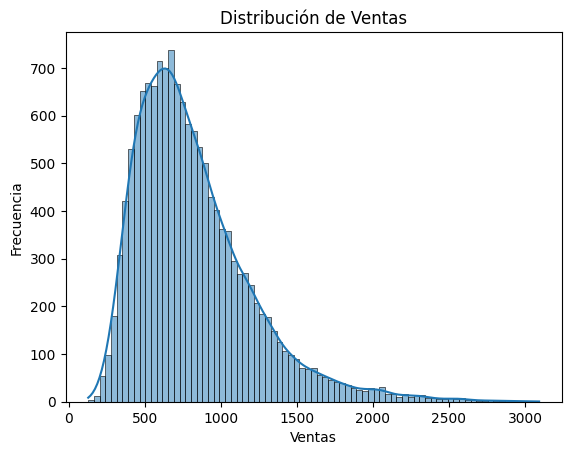

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma de ventas
sns.histplot(data=data, x="Ventas", kde=True)
plt.title("Distribución de Ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

- **Actividad:**
  - Analizar la distribución de las ventas en cada región y categoría de producto.
  - Preguntas a resolver: ¿Son las ventas uniformes entre regiones? ¿Hay regiones con distribuciones sesgadas?

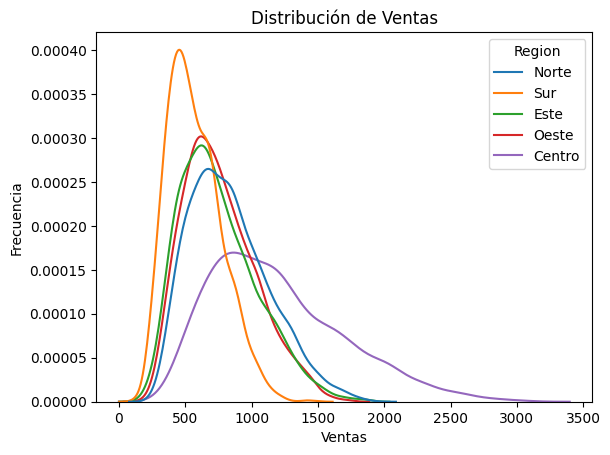

In [62]:
# Histograma de ventas
sns.kdeplot(data=data, x="Ventas", hue="Region")
plt.title("Distribución de Ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

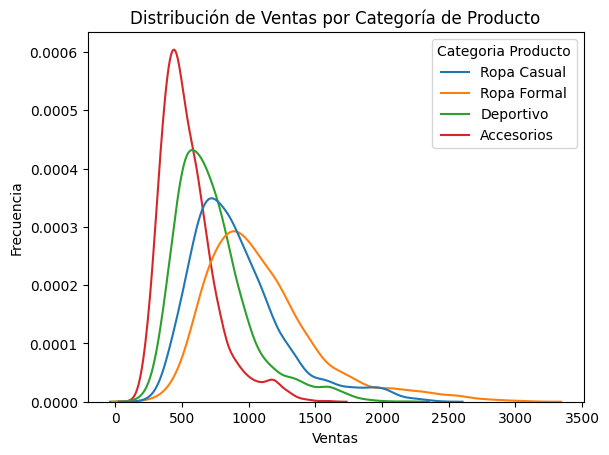

In [63]:
# Histograma de ventas
sns.kdeplot(data=data, x="Ventas", hue="Categoria Producto")
plt.title("Distribución de Ventas por Categoría de Producto")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

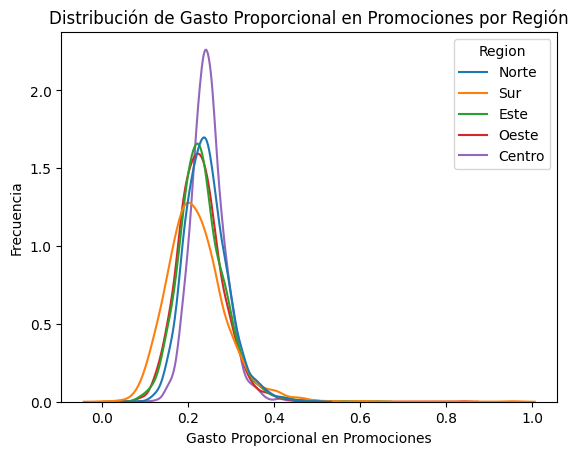

In [64]:
# Histograma de Gasto%
sns.kdeplot(data=data, x="Gasto Promociones%", hue="Region")
plt.title("Distribución de Gasto Proporcional en Promociones por Región")
plt.xlabel("Gasto Proporcional en Promociones")
plt.ylabel("Frecuencia")
plt.show()

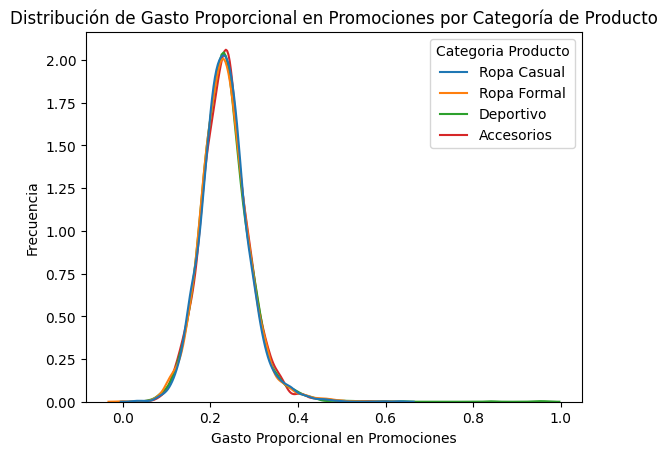

In [65]:
# Histograma de Gasto%
sns.kdeplot(data=data, x="Gasto Promociones%", hue="Categoria Producto")
plt.title("Distribución de Gasto Proporcional en Promociones por Categoría de Producto")
plt.xlabel("Gasto Proporcional en Promociones")
plt.ylabel("Frecuencia")
plt.show()

- Ya sabemos que hay alta variabilidad en las ventas por región

- También sabemos que hay alta variabilidad en ventas por categoría de producto

- **NO** parece haber un gasto diferenciado por categoría de producto

- **Actividad:**
  - Analizar box-plot por region y categoria

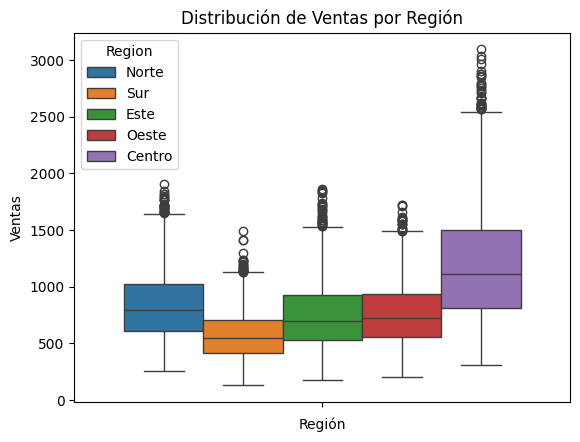

In [66]:
# Boxplot ventas
sns.boxplot(data=data, y="Ventas", hue="Region")
plt.title("Distribución de Ventas por Región")
plt.xlabel("Región")
plt.ylabel("Ventas")
plt.show()

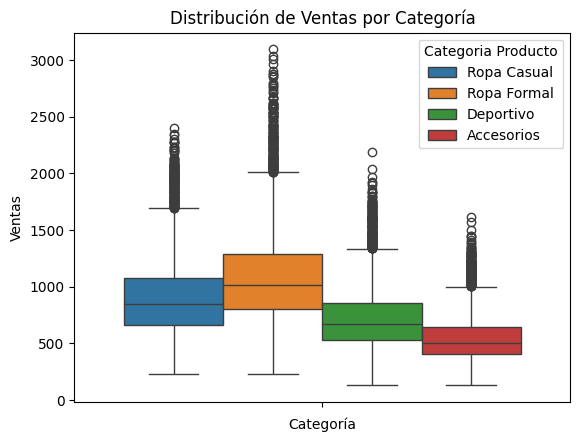

In [67]:
# Boxplot ventas
sns.boxplot(data=data, y="Ventas", hue="Categoria Producto")
plt.title("Distribución de Ventas por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")
plt.show()


---

**5. Cierre y Reflexión (10 minutos):**

- Utilizar analisis descriptivo para tomar decisiones
